In [1]:
import os
# Ensure deterministic CuBLAS workspace for reproducibility when
# `torch.use_deterministic_algorithms(True)` is enabled. This must be set
# before any CUDA/CuBLAS initialization (i.e. before importing torch or
# creating CUDA tensors). Use ':4096:8' or ':16:8' as recommended by NVIDIA.
if 'CUBLAS_WORKSPACE_CONFIG' not in os.environ:
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
import math
import time
from typing import Optional, Tuple, List

import numpy as np
import torch
import random
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
import gymnasium as gym
from gymnasium.vector import SyncVectorEnv

# Utilities: vector env factory

def make_env_fn(env_id: str, seed: int = 0, render_mode: Optional[str]=None):
    def _thunk():
        # pass render_mode to gym.make when provided (needed to get image observations)
        if render_mode is not None:
            env = gym.make(env_id, render_mode=render_mode)
        else:
            env = gym.make(env_id)
        if seed is not None:
            try:
                env.reset(seed=seed)
            except TypeError:
                pass
        return env
    return _thunk


# convenience: create SyncVectorEnv from gymnasium
def make_vector_envs(env_id: str, num_envs: int, base_seed: int = 0, render_mode: Optional[str]=None):
    fns = [make_env_fn(env_id, seed=base_seed + i, render_mode=render_mode) for i in range(num_envs)]
    return SyncVectorEnv(fns)


def set_global_seed(seed: int):
    """Set seeds for python, numpy, torch and configure deterministic behavior.

    Note: full determinism across different hardware and library versions is not guaranteed,
    but this sets the recommended flags to maximize reproducibility.
    """
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    # torch deterministic settings
    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        # older torch
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


def load_vit_backbone(backbone_name: str = "vit_b_16", device: Optional[torch.device] = None, dino_ckpt_path: Optional[str] = None, obs_space=None):
   
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # if the observation space is not image-shaped, return an identity backbone
    if obs_space is not None:
        shape = getattr(obs_space, 'shape', None)
        if shape is not None and len(shape) != 3:
            # vector observation
            class IdentityBackbone(nn.Module):
                def __init__(self, dim):
                    super().__init__()
                    self.dim = dim
                def forward(self, x):
                    return x
            feat_dim = int(np.prod(shape)) if shape is not None else 1
            return IdentityBackbone(feat_dim), feat_dim

    if backbone_name == "dino_v2" and dino_ckpt_path is not None:
        # TODO: implement actual DINO-v2 checkpoint loading depending on format.
        raise NotImplementedError("Please replace loader with your DINO-v2 checkpoint loading code and mapping.")
    else:
        # fallback: torchvision ViT base 16
        vit = models.vit_b_16(pretrained=True)
        feat_dim = vit.heads.head.in_features if hasattr(vit, "heads") and hasattr(vit.heads, "head") else vit.hidden_dim
        vit.heads = nn.Identity()
        vit.to(device)
        vit.eval()
        return vit, feat_dim


def default_image_transform():
    return transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),  # DINO / ViT default
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])


class Projector(nn.Module):
    def __init__(self, in_dim: int, proj_dim: int = 256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, in_dim),
            nn.GELU(),
            nn.Linear(in_dim, proj_dim),
            nn.LayerNorm(proj_dim),
        )

    def forward(self, x):
        # x: [B, in_dim]
        return self.net(x)

# ----------------------------
# Simple Transformer-XL style recurrent module
# - We'll implement a causal Transformer encoder and support concatenating memory (memory_len tokens)
# - Memory is a tensor [memory_len, batch, dim] for each batch
# - We represent each time-step's state as a single token (per-frame embedding)
# ----------------------------
def causal_attention_mask(sz_q: int, sz_k: int, device):
    # returns mask shape (sz_q, sz_k) True where masked
    # we want to allow attending only to <= current position (causal)
    idxs_q = torch.arange(sz_q, device=device)[:, None]
    idxs_k = torch.arange(sz_k, device=device)[None, :]
    mask = idxs_k > idxs_q  # True where k > q (disallowed)
    return mask  # (sz_q, sz_k)

class SmallCausalTransformer(nn.Module):
    def __init__(self, d_model=512, nhead=8, num_layers=2, dim_feedforward=2048, dropout=0.1):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                                   dim_feedforward=dim_feedforward,
                                                   dropout=dropout,
                                                   activation='gelu',
                                                   batch_first=False)  # we'll use seq_len x batch x d
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def forward(self, x: torch.Tensor, attn_mask: Optional[torch.Tensor] = None):
        # x: seq_len x batch x d_model
        # transformer expects src_mask shape (seq_len, seq_len) with True where masked
        return self.transformer(x, mask=attn_mask)


# Policy: takes sequences of projected embeddings + recurrent memory -> action logits/means + value

class RecurrentPolicy(nn.Module):
    def __init__(
        self,
        proj_dim: int,
        action_space,
        transformer_d_model: int = 512,
        transformer_heads: int = 8,
        transformer_layers: int = 2,
        memory_segments: int = 4,
        segment_length: int = 16,
        compress_ratio: int = 1,  # compression for old segments (1 = no compression)
        device: Optional[torch.device] = None,
        fine_tune_backbone: bool = False,
    ):
        super().__init__()
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.proj_dim = proj_dim
        self.d_model = transformer_d_model
        # a linear to map proj_dim to transformer d_model
        self.input_mapper = nn.Linear(proj_dim, transformer_d_model)
        self.transformer = SmallCausalTransformer(d_model=transformer_d_model,
                                                  nhead=transformer_heads,
                                                  num_layers=transformer_layers)
        # heads
        if isinstance(action_space, gym.spaces.Discrete):
            self.is_discrete = True
            self.action_dim = action_space.n
            self.policy_head = nn.Linear(transformer_d_model, self.action_dim)
        elif isinstance(action_space, gym.spaces.Box):
            self.is_discrete = False
            self.action_dim = int(np.prod(action_space.shape))
            self.policy_head = nn.Linear(transformer_d_model, self.action_dim)
            self.logstd = nn.Parameter(torch.zeros(self.action_dim, device=self.device))
        else:
            raise NotImplementedError("Action space not supported")

        self.value_head = nn.Linear(transformer_d_model, 1)
        self.memory_segments = memory_segments
        self.segment_length = segment_length
        self.compress_ratio = max(1, compress_ratio)

        # initialize memory buffers externally per env (see trainer)
        # move to device
        self.to(self.device)

    def forward_sequence(self, seq_proj: torch.Tensor, memory: Optional[torch.Tensor] = None):

        T, N, _ = seq_proj.shape
        x = self.input_mapper(seq_proj)  # [T, N, d_model]
        if memory is not None:
            # map memory to d_model and concat (memory first, then current sequence)
            mem_mapped = self.input_mapper(memory)  # [M, N, d_model]
            cat = torch.cat([mem_mapped, x], dim=0)  # [M+T, N, d_model]
            seq = cat
            mem_len = mem_mapped.shape[0]
        else:
            seq = x
            mem_len = 0

        # build causal mask so positions can attend to previous positions (including memory)
        seq_len = seq.shape[0]
        mask = causal_attention_mask(seq_len, seq_len, device=seq.device)  # True masked
        out = self.transformer(seq, attn_mask=mask)  # [seq_len, N, d_model]
        # take only the last T outputs (corresponding to current sequence)
        out_current = out[mem_len:]  # [T, N, d_model]
        # compute policy & value per timestep
        if self.is_discrete:
            logits = self.policy_head(out_current)  # [T, N, action_dim]
            values = self.value_head(out_current).squeeze(-1)  # [T, N]
            return logits, values
        else:
            mean = self.policy_head(out_current)
            std = torch.exp(self.logstd).unsqueeze(0).expand_as(mean)
            values = self.value_head(out_current).squeeze(-1)
            return (mean, std), values

    def init_memory(self, num_envs: int, device: Optional[torch.device] = None):
        device = device or self.device
        # memory represented in proj_dim space (same space as projector output)
        # We'll store memory in proj_dim space for easier compression / storage.
        mem_slots = self.memory_segments * self.segment_length // self.compress_ratio
        # shape [M, N, proj_dim]
        return torch.zeros((mem_slots, num_envs, self.proj_dim), device=device)

    def update_memory(self, memory: torch.Tensor, new_seq_proj: torch.Tensor):

        M, N, D = memory.shape
        T = new_seq_proj.shape[0]
        # flatten memory timeline -> last K tokens
        combined = torch.cat([memory, new_seq_proj], dim=0)  # [M+T, N, D]
        # keep last M tokens
        new_mem = combined[-M:]
        return new_mem.detach()  # detach to avoid backprop through old memory


# Helper: utilities for image batches processing

def preprocess_observations(obs_batch: np.ndarray, transform):

    # support uint8 inputs and both image and vector observations
    N = obs_batch.shape[0]
    # if channels last image HWC
    if transform is not None and obs_batch.ndim == 4 and obs_batch.shape[-1] in (1, 3):
        imgs = []
        for i in range(N):
            img = obs_batch[i]
            img_t = transform(img)  # returns C,H,W tensor
            imgs.append(img_t)
        imgs = torch.stack(imgs, dim=0)
        return imgs
    else:
        # vector observations or already CHW tensors
        if obs_batch.dtype == np.uint8:
            obs_batch = obs_batch.astype(np.float32) / 255.0
        return torch.from_numpy(obs_batch).float()


# PPO Trainer (with memory & multi-env)

class PPOTrainer:
    def __init__(
        self,
        env_id: str,
        seed: int = 0,
        num_envs: int = 8,
        device: Optional[torch.device] = None,
        total_steps: int = 200_000,
        rollout_length: int = 128,
        learning_rate: float = 3e-4,
        gamma: float = 0.99,
        lam: float = 0.95,
        ppo_clip: float = 0.2,
        ppo_epochs: int = 4,
        minibatch_size: int = 256,
        backbone_name: str = "vit_b_16",
        dino_ckpt_path: Optional[str] = None,
        proj_dim: int = 256,
        transformer_d_model: int = 512,
        transformer_layers: int = 2,
        memory_segments: int = 4,
        segment_length: int = 16,
        compress_ratio: int = 1,
        freeze_backbone: bool = True,
        render_mode: Optional[str] = None,
        save_dir: str = "checkpoints",
    ):
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        # global seed for reproducibility
        self.seed = seed
        set_global_seed(self.seed)
        # allow specifying render_mode so envs can return image observations when needed
        self.render_mode = render_mode
        self.num_envs = num_envs
        self.env_id = env_id
        self.total_steps = total_steps
        self.rollout_length = rollout_length
        self.gamma = gamma
        self.lam = lam
        self.ppo_clip = ppo_clip
        self.ppo_epochs = ppo_epochs
        self.minibatch_size = minibatch_size
        self.save_dir = save_dir
        os.makedirs(self.save_dir, exist_ok=True)

        # create vector envs (use provided seed as base_seed so envs are reproducible)
        self.envs = make_vector_envs(env_id, num_envs, base_seed=self.seed, render_mode=self.render_mode)
        self.obs_space = self.envs.single_observation_space
        self.action_space = self.envs.single_action_space

        # backbone selection (image vs vector observations)
        self.backbone, feat_dim = load_vit_backbone(backbone_name, device=self.device, dino_ckpt_path=dino_ckpt_path, obs_space=self.obs_space)
        self.backbone_name = backbone_name
        self.backbone_feature_dim = feat_dim
        self.transform = default_image_transform()

        # projector
        self.projector = Projector(in_dim=feat_dim, proj_dim=proj_dim).to(self.device)

        # policy
        self.policy = RecurrentPolicy(proj_dim=proj_dim,
                                      action_space=self.action_space,
                                      transformer_d_model=transformer_d_model,
                                      transformer_heads=8,
                                      transformer_layers=transformer_layers,
                                      memory_segments=memory_segments,
                                      segment_length=segment_length,
                                      compress_ratio=compress_ratio,
                                      device=self.device).to(self.device)

        # optionally freeze backbone
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        # optimizer includes policy, projector, and optionally backbone
        params = list(self.policy.parameters()) + list(self.projector.parameters())
        if not freeze_backbone:
            params += [p for p in self.backbone.parameters() if p.requires_grad]
        self.optimizer = optim.Adam(params, lr=learning_rate, eps=1e-5)

        # memory buffers per env (projector-space memory)
        self.memory = self.policy.init_memory(num_envs=self.num_envs, device=self.device)  # [M, N, proj_dim]

    def extract_backbone_features(self, imgs_tensor: torch.Tensor) -> torch.Tensor:

        # pass through ViT backbone which expects [B, C, H, W]
        with torch.no_grad() if not any(p.requires_grad for p in self.backbone.parameters()) else torch.enable_grad():
            feats = self.backbone(imgs_tensor.to(self.device))
        return feats  # [B, feat_dim]

    def project_obs(self, obs_batch: np.ndarray) -> torch.Tensor:
        imgs_t = preprocess_observations(obs_batch, self.transform).to(self.device)  # [N, C, H, W]
        feats = self.extract_backbone_features(imgs_t)  # [N, feat_dim]
        proj = self.projector(feats)  # [N, proj_dim]
        return proj  # [N, proj_dim]

    def compute_gae(self, rewards, values, dones):

        T, N = rewards.shape
        returns = np.zeros_like(rewards)
        advs = np.zeros_like(rewards)
        last_gae_lam = np.zeros(N)
        next_values = np.zeros(N)
        for t in reversed(range(T)):
            next_nonterminal = 1.0 - dones[t]
            delta = rewards[t] + self.gamma * next_values * next_nonterminal - values[t]
            last_gae_lam = delta + self.gamma * self.lam * next_nonterminal * last_gae_lam
            advs[t] = last_gae_lam
            returns[t] = advs[t] + values[t]
            next_values = values[t]
        return returns, advs

    def save_checkpoint(self, step:int):
        ckpt = {
            'backbone_name': self.backbone_name,
            'backbone_state': self.backbone.state_dict(),
            'projector_state': self.projector.state_dict(),
            'policy_state': self.policy.state_dict(),
            'optimizer_state': self.optimizer.state_dict(),
            'memory': self.memory.cpu(),
            'step': step
        }
        path = os.path.join(self.save_dir, f"ckpt_{step}.pth")
        torch.save(ckpt, path)
        print(f"Saved checkpoint: {path}")

    def load_checkpoint(self, path: str):
        ckpt = torch.load(path, map_location=self.device)
        # load states; be mindful if architecture changed
        self.backbone.load_state_dict(ckpt['backbone_state'], strict=False)
        self.projector.load_state_dict(ckpt['projector_state'], strict=False)
        self.policy.load_state_dict(ckpt['policy_state'], strict=False)
        self.optimizer.load_state_dict(ckpt['optimizer_state'])
        self.memory = ckpt['memory'].to(self.device)
        print(f"Loaded checkpoint: {path}")

    def train(self):
        obs_reset = self.envs.reset()
        # gymnasium.reset() returns (obs, infos) for vector envs; handle both forms
        if isinstance(obs_reset, tuple) and len(obs_reset) == 2:
            obs, _ = obs_reset
        else:
            obs = obs_reset
        # make sure obs is numpy array [N, ...]
        total_steps = 0
        start_time = time.time()
        ep_returns = np.zeros(self.num_envs)
        ep_lengths = np.zeros(self.num_envs)
        episode_info = []

        while total_steps < self.total_steps:
            # rollout buffers
            imgs_buf = []
            proj_buf = []  # projected embeddings per time
            actions_buf = []
            logp_buf = []
            rewards_buf = []
            dones_buf = []
            values_buf = []

            # we will collect rollout_length steps
            for step in range(self.rollout_length):
                # prepare images -> proj embeddings
                proj = self.project_obs(obs)  # [N, proj_dim]
                # reshape to [1, N, proj_dim] for sequence step
                proj_step = proj.unsqueeze(0)  # [1, N, D]
                # supply memory (proj-space) to policy
                with torch.no_grad():
                    policy_out, value = self.policy.forward_sequence(seq_proj=proj_step, memory=self.memory)
                    # policy_out: logits [1,N,A] or (mean,std) for continuous
                    value_np = value.squeeze(0).cpu().numpy()  # [N]
                    values_buf.append(value_np)
                    if self.policy.is_discrete:
                        logits = policy_out.squeeze(0)  # [N,A]
                        probs = torch.softmax(logits, dim=-1)
                        actions = torch.multinomial(probs, num_samples=1).squeeze(-1).cpu().numpy()
                        logp = torch.log_softmax(logits, dim=-1).gather(1, torch.from_numpy(actions).to(self.device).unsqueeze(1)).squeeze(1).cpu().numpy()
                    else:
                        mean, std = policy_out
                        dist = torch.distributions.Normal(mean.squeeze(0), std.squeeze(0))
                        actions_t = dist.sample()
                        actions = actions_t.cpu().numpy()
                        logp = dist.log_prob(actions_t).sum(-1).cpu().numpy()

                # step envs
                step_ret = self.envs.step(actions)
                # gymnasium VectorEnv.step returns either
                # (obs, rewards, terminated, truncated, infos) or the older (obs, rewards, dones, infos)
                if isinstance(step_ret, tuple) and len(step_ret) == 5:
                    next_obs, rewards, terminated, truncated, infos = step_ret
                    dones = np.logical_or(terminated, truncated)
                elif isinstance(step_ret, tuple) and len(step_ret) == 4:
                    next_obs, rewards, dones, infos = step_ret
                else:
                    raise RuntimeError(f"Unexpected return from envs.step: len={len(step_ret) if isinstance(step_ret, tuple) else 'unknown'}")
                imgs_buf.append(obs)  # store raw obs for potential diagnostics
                proj_buf.append(proj.detach().cpu().numpy())  # store proj (for memory updates after rollout)
                actions_buf.append(actions)
                logp_buf.append(logp)
                rewards_buf.append(rewards)
                dones_buf.append(dones)
                values_buf[-1] = value_np  # ensured

                # bookkeeping
                ep_returns += rewards
                ep_lengths += 1
                for i, d in enumerate(dones):
                    if d:
                        episode_info.append({"reward": float(ep_returns[i]), "length": int(ep_lengths[i])})
                        ep_returns[i] = 0
                        ep_lengths[i] = 0

                obs = next_obs
                total_steps += self.num_envs

            # convert buffers -> arrays for PPO updates
            # shapes: [T, N, ...]
            rewards_arr = np.stack(rewards_buf, axis=0)
            dones_arr = np.stack(dones_buf, axis=0).astype(np.float32)
            values_arr = np.stack(values_buf, axis=0)
            actions_arr = np.stack(actions_buf, axis=0)
            logp_arr = np.stack(logp_buf, axis=0)
            proj_arr = np.stack(proj_buf, axis=0)  # [T, N, proj_dim]

            # compute returns and advantages
            returns, advs = self.compute_gae(rewards_arr, values_arr, dones_arr)
            # flatten for optimization
            T, N = returns.shape
            flat_returns = returns.reshape(T * N)
            flat_advs = advs.reshape(T * N)
            flat_actions = actions_arr.reshape(T * N, -1) if (not self.policy.is_discrete) else actions_arr.reshape(T * N)
            flat_logp_old = logp_arr.reshape(T * N)
            flat_proj = proj_arr.reshape(T * N, -1)  # flatten

            # We'll perform PPO updates using minibatches sampled from T*N examples.
            # To compute current logp & values we process in minibatches by reconstructing sequences
            # For simplicity we'll process per timestep (no long sequences for transformer during updates), but keep memory usage okay.
            # NOTE: this is an approximation — for precise segment-level recurrence training you'd run sequences through the transformer with the same memory as used during collection.
            # We'll use the memory as it stands (self.memory) and process each timestep independently by feeding memory + single timestep.
            # Prepare dataset indices
            batch_size = T * N
            idxs = np.arange(batch_size)
            for epoch in range(self.ppo_epochs):
                np.random.shuffle(idxs)
                for start in range(0, batch_size, self.minibatch_size):
                    mb_idx = idxs[start:start + self.minibatch_size]
                    # convert flat indices -> (t, n)
                    t_idx = (mb_idx // N).astype(int)
                    n_idx = (mb_idx % N).astype(int)
                    # gather proj tokens for this minibatch
                    mb_proj = torch.from_numpy(flat_proj[mb_idx]).to(self.device).float()  # [B, proj_dim]
                    # reshape to seq_len 1 for transformer's forward
                    mb_seq = mb_proj.unsqueeze(0)  # [1, B, proj_dim]
                    # create memory for each minibatch element by indexing self.memory along env dim
                    # memory: [M, N, D] -> we need [M, B, D]
                    # gather along env dimension
                    mem = self.memory[:, n_idx, :].to(self.device)  # [M, B, D]
                    # forward
                    policy_out, value_pred = self.policy.forward_sequence(seq_proj=mb_seq, memory=mem)
                    # policy_out -> [1, B, A] etc.
                    if self.policy.is_discrete:
                        logits = policy_out.squeeze(0)  # [B, A]
                        logp_all = torch.log_softmax(logits, dim=-1)
                        # gather action logp
                        mb_actions = torch.from_numpy(flat_actions[mb_idx]).to(self.device).long()
                        logp = logp_all.gather(1, mb_actions.unsqueeze(1)).squeeze(1)
                        entropy = -(torch.exp(logp_all) * logp_all).sum(-1).mean()
                    else:
                        mean, std = policy_out
                        mean = mean.squeeze(0)
                        std = std.squeeze(0)
                        dist = torch.distributions.Normal(mean, std)
                        mb_actions = torch.from_numpy(flat_actions[mb_idx]).to(self.device).float()
                        logp = dist.log_prob(mb_actions).sum(-1)
                        entropy = dist.entropy().sum(-1).mean()

                    value_pred = value_pred.squeeze(0)  # [B]
                    # compute advantages & returns for minibatch
                    mb_returns = torch.from_numpy(flat_returns[mb_idx]).to(self.device).float()
                    mb_advs = torch.from_numpy(flat_advs[mb_idx]).to(self.device).float()
                    mb_logp_old = torch.from_numpy(flat_logp_old[mb_idx]).to(self.device).float()

                    ratio = torch.exp(logp - mb_logp_old)
                    surr1 = ratio * mb_advs
                    surr2 = torch.clamp(ratio, 1.0 - self.ppo_clip, 1.0 + self.ppo_clip) * mb_advs
                    policy_loss = -torch.min(surr1, surr2).mean()
                    value_loss = 0.5 * (mb_returns - value_pred).pow(2).mean()
                    loss = policy_loss + 0.5 * value_loss - 0.01 * entropy

                    self.optimizer.zero_grad()
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(self.policy.parameters(), 0.5)
                    self.optimizer.step()

            # After optimization, update memory by appending last rollout's proj tokens (we append per env)
            # proj_arr: [T, N, D]
            proj_torch = torch.from_numpy(proj_arr).to(self.device).float()  # [T, N, D]
            # append sequentially: for each env, update memory with last segment_length tokens; here we update memory globally by using the T last tokens.
            # Reshape proj_torch into [T, N, D] and update memory using policy.update_memory
            # For simplicity, we call update_memory once with the last segment_length steps
            last_segment = proj_torch[-self.policy.segment_length:] if proj_torch.shape[0] >= self.policy.segment_length else proj_torch
            # last_segment: [t', N, D] where t' <= segment_length
            # pad if needed to segment_length by repeating last
            if last_segment.shape[0] < self.policy.segment_length:
                pad = self.policy.segment_length - last_segment.shape[0]
                pad_t = last_segment[-1:].expand(pad, -1, -1)
                last_segment = torch.cat([last_segment, pad_t], dim=0)
            # update memory
            self.memory = self.policy.update_memory(self.memory, last_segment.cpu().to(self.device))

            # logging
            elapsed = time.time() - start_time
            avg_return = np.mean([e['reward'] for e in episode_info[-50:]]) if len(episode_info) > 0 else 0.0
            print(f"Steps: {total_steps}/{self.total_steps}, elapsed: {elapsed:.1f}s, recent_avg_return: {avg_return:.2f}")

            # save checkpoint periodically
            if total_steps % (self.rollout_length * self.num_envs * 10) == 0:
                self.save_checkpoint(total_steps)

        # final save
        self.save_checkpoint(total_steps)
        self.envs.close()


# Main: run trainer with defaults

# if __name__ == "__main__":
#     # CHANGE THESE to match your environment & compute
#     ENV_ID = "CartPole-v1"  # replace with visual env (should output images)
#     NUM_ENVS = 8
#     TOTAL_STEPS = 50_000  # for quick test; increase for real training
#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#     # global seed for reproducibility across runs/GPUs
#     SEED = 0

#     trainer = PPOTrainer(
#         env_id=ENV_ID,
#         seed=SEED,
#         num_envs=NUM_ENVS,
#         device=device,
#         total_steps=TOTAL_STEPS,
#         rollout_length=64,
#         learning_rate=2.5e-4,
#         gamma=0.99,
#         lam=0.95,
#         ppo_clip=0.2,
#         ppo_epochs=4,
#         minibatch_size=256,
#         backbone_name="vit_b_16",  # swap to "dino_v2" and provide dino_ckpt_path for DINO
#         dino_ckpt_path=None,
#         proj_dim=256,
#         transformer_d_model=512,
#         transformer_layers=2,
#         memory_segments=4,
#         segment_length=16,
#         compress_ratio=1,
#         freeze_backbone=True,
#         save_dir="checkpoints"
#   )

# [NEW Recommended __main__ block for LunarLander-v3]

if __name__ == "__main__":
    # === Tuned for LunarLander-v3 (Visual) ===
    ENV_ID = "LunarLander-v3"
    NUM_ENVS = 8
    TOTAL_STEPS = 2_000_000  # Much harder env, needs more steps!
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    SEED = 0
    # CRITICAL: We MUST tell the env to give us pixels!
    RENDER_MODE = "rgb_array" 

    trainer = PPOTrainer(
        env_id=ENV_ID,
        seed=SEED,
        num_envs=NUM_ENVS,
        device=device,
        total_steps=TOTAL_STEPS,
        rollout_length=2048,      # <-- INCREASED: Needs long horizon for sparse reward
        learning_rate=1e-4,       # <-- DECREASED: More stable for harder task
        gamma=0.99,               # <-- Stays high (good for sparse reward)
        lam=0.95,
        ppo_clip=0.2,
        ppo_epochs=10,            # <-- INCREASED: Learn more from each rollout
        minibatch_size=256,       # <-- OK: (2048*8) / 256 = 64 minibatches
        backbone_name="vit_b_16",
        dino_ckpt_path=None,
        proj_dim=256,
        transformer_d_model=512,
        transformer_layers=2,
        memory_segments=4,
        segment_length=16,
        compress_ratio=1,
        freeze_backbone=True,
        render_mode=RENDER_MODE,  # <-- ADDED: Pass this to the env!
        save_dir="checkpoints_lunarlander" # <-- Optional: new save dir
    )

    trainer.train()


/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Steps: 16384/2000000, elapsed: 26.0s, recent_avg_return: -240.07
Steps: 32768/2000000, elapsed: 50.7s, recent_avg_return: -175.51
Steps: 49152/2000000, elapsed: 74.1s, recent_avg_return: -138.52
Steps: 65536/2000000, elapsed: 99.3s, recent_avg_return: -106.92
Steps: 81920/2000000, elapsed: 124.2s, recent_avg_return: -85.84
Steps: 98304/2000000, elapsed: 149.1s, recent_avg_return: -62.61
Steps: 114688/2000000, elapsed: 173.1s, recent_avg_return: -50.78
Steps: 131072/2000000, elapsed: 199.1s, recent_avg_return: -36.43
Steps: 147456/2000000, elapsed: 223.6s, recent_avg_return: -17.75
Steps: 163840/2000000, elapsed: 250.1s, recent_avg_return: -16.14
Saved checkpoint: checkpoints_lunarlander/ckpt_163840.pth
Steps: 180224/2000000, elapsed: 277.8s, recent_avg_return: 3.52
Steps: 196608/2000000, elapsed: 305.2s, recent_avg_return: 11.68
Steps: 212992/2000000, elapsed: 334.2s, recent_avg_return: 17.90
Steps: 229376/2000000, elapsed: 363.0s, recent_avg_return: 2.03
Steps: 245760/2000000, elapsed

In [8]:
#!/usr/bin/env python3



import os
# Ensure deterministic CuBLAS workspace for reproducibility when
# `torch.use_deterministic_algorithms(True)` is enabled. This must be set
# before any CUDA/CuBLAS initialization. Set default if not provided.
if 'CUBLAS_WORKSPACE_CONFIG' not in os.environ:
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
import argparse
import json
import csv
import time
import logging
import traceback
from collections import defaultdict
import numpy as np
import torch
try:
    import gymnasium as gym
except Exception:
    import gym
# import matplotlib.pyplot as plt  # Not used in production

# Import your trainer (adjust path if needed)

def safe_torch_load(path, map_location):
    # Try weights_only (newer PyTorch) else fallback
    try:
        return torch.load(path, map_location=map_location, weights_only=True)
    except TypeError:
        # older torch doesn't have weights_only arg
        return torch.load(path, map_location=map_location)
    except Exception as e:
        logging.warning(f"Fallback torch.load for {path}: {e}")
        return torch.load(path, map_location=map_location)

def debug_print_actions_sample(all_actions, max_eps=3):
    logging.info("=== Debug: sample action types/shapes for first episodes ===")
    for ei, ep_actions in enumerate(all_actions[:max_eps]):
        sample_info = []
        for ai, a in enumerate(ep_actions[:5]):
            sample_info.append((type(a).__name__, np.shape(a)))
        logging.info(f"Episode {ei}: first_actions types/shapes: {sample_info}")

def evaluate_checkpoint(trainer: PPOTrainer, ckpt_path: str, env_id: str, num_episodes: int = 20, deterministic: bool = True, max_steps_per_episode: int = 1000):
    env = gym.make(env_id)
    # safe load with diagnostics
    try:
        ckpt = safe_torch_load(ckpt_path, map_location=trainer.device)
    except Exception as e:
        logging.error(f"Failed to torch.load checkpoint {ckpt_path}: {e}")
        raise RuntimeError(f"Failed to torch.load checkpoint {ckpt_path}: {e}")

    # Try to load states safely; support multiple naming conventions
    try:
        # common keys
        if isinstance(ckpt, dict) and ('policy_state' in ckpt or 'policy' in ckpt or 'projector_state' in ckpt):
            # attempt to load sub-keys
            # load policy state if present
            if 'policy_state' in ckpt:
                missing, unexpected = trainer.policy.load_state_dict(ckpt['policy_state'], strict=False)
                logging.info(f"policy load missing keys: {missing} unexpected: {unexpected}")
            elif 'policy' in ckpt:
                missing, unexpected = trainer.policy.load_state_dict(ckpt['policy'], strict=False)
                logging.info(f"policy load missing keys: {missing} unexpected: {unexpected}")
            if 'projector_state' in ckpt:
                trainer.projector.load_state_dict(ckpt['projector_state'], strict=False)
            if 'backbone_state' in ckpt:
                trainer.backbone.load_state_dict(ckpt['backbone_state'], strict=False)
            if 'optimizer_state' in ckpt and hasattr(trainer, 'optimizer'):
                try:
                    trainer.optimizer.load_state_dict(ckpt['optimizer_state'])
                except Exception as ee:
                    logging.warning(f"Could not load optimizer state: {ee}")
            # memory if available
            if 'memory' in ckpt:
                try:
                    trainer.memory = ckpt['memory'].to(trainer.device)
                except Exception:
                    trainer.memory = ckpt['memory']
        else:
            # If checkpoint is just a state_dict for a model, try to load into policy
            try:
                missing, unexpected = trainer.policy.load_state_dict(ckpt, strict=False)
                logging.info(f"Loaded checkpoint as policy state_dict. missing: {missing} unexpected: {unexpected}")
            except Exception:
                # try loading into whole trainer
                try:
                    trainer_state = ckpt
                    # attempt keys if present
                    if 'policy_state_dict' in trainer_state:
                        trainer.policy.load_state_dict(trainer_state['policy_state_dict'], strict=False)
                    else:
                        # final fallback: ignore
                        pass
                except Exception:
                    pass
    except Exception as e:
        logging.warning(f"Warning: unexpected checkpoint structure. Proceeding, but you may see eval errors. Err: {e}")

    trainer.backbone.eval(); trainer.projector.eval(); trainer.policy.eval()

    returns = []; lengths = []; all_actions = []; all_values = []
    try:
        memory = trainer.memory[:, 0:1, :].to(trainer.device).clone()
    except Exception as e:
        logging.warning(f"Could not clone trainer memory: {e}")
        memory = None

    for ep in range(num_episodes):
        try:
            obs_reset = env.reset()
            if isinstance(obs_reset, tuple) and len(obs_reset) >= 1:
                obs = obs_reset[0]
            else:
                obs = obs_reset
            done = False; total = 0.0; length = 0
            episode_actions = []; episode_values = []
            mem = memory.clone() if memory is not None else None
            while (not done) and (length < max_steps_per_episode):
                proj = trainer.project_obs(np.expand_dims(obs, 0))  # [1, D]
                with torch.no_grad():
                    try:
                        policy_out, value = trainer.policy.forward_sequence(seq_proj=proj.unsqueeze(0), memory=mem)
                    except Exception as e:
                        logging.error(f"Error running policy.forward_sequence: {e}")
                        raise
                    if trainer.policy.is_discrete:
                        logits = policy_out.squeeze(0).squeeze(0)
                        if deterministic:
                            action = int(torch.argmax(logits).cpu().item())
                        else:
                            probs = torch.softmax(logits, dim=-1)
                            action = int(torch.multinomial(probs, 1).cpu().item())
                    else:
                        mean, std = policy_out
                        mean = mean.squeeze(0).squeeze(0).cpu.numpy()
                        if deterministic:
                            action = mean
                        else:
                            action = np.random.normal(mean, std.squeeze(0).squeeze(0).cpu().numpy())
                    pred_value = float(value.squeeze(0).squeeze(0).cpu().item())
                step_ret = env.step(action)
                if isinstance(step_ret, tuple) and len(step_ret) == 5:
                    next_obs, reward, terminated, truncated, info = step_ret
                    done = bool(terminated or truncated)
                elif isinstance(step_ret, tuple) and len(step_ret) == 4:
                    next_obs, reward, done, info = step_ret
                else:
                    raise RuntimeError(f"Unexpected env.step return of length {len(step_ret) if isinstance(step_ret, tuple) else 'unknown'}")
                total += reward; length += 1
                episode_actions.append(action); episode_values.append(pred_value)
                try:
                    proj_token = proj.unsqueeze(0).cpu()
                    if mem is not None:
                        mem = trainer.policy.update_memory(mem, proj_token.to(trainer.device))
                except Exception as e:
                    logging.debug(f"Memory update failed: {e}")
                obs = next_obs
            returns.append(total); lengths.append(length)
            all_actions.append(episode_actions); all_values.append(episode_values)
            logging.info(f"Episode {ep}: return={total:.2f}, steps={length}")
        except Exception as e:
            logging.error(f"Error in episode {ep}: {e}")
            continue

    # debug print sample shapes
    debug_print_actions_sample(all_actions, max_eps=3)

    # safe aggregation
    flat_values = np.concatenate([np.array(v) for v in all_values if len(v) > 0]) if any(len(v)>0 for v in all_values) else np.array([])
    avg_pred_values = np.array([np.mean(v) if len(v) > 0 else 0.0 for v in all_values])
    episode_returns = np.array(returns)

    metrics = {
        "ckpt": ckpt_path,
        "num_episodes": num_episodes,
        "mean_return": float(np.mean(returns)),
        "std_return": float(np.std(returns)),
        "median_return": float(np.median(returns)),
        "min_return": float(np.min(returns)),
        "max_return": float(np.max(returns)),
        "mean_length": float(np.mean(lengths)),
        "std_length": float(np.std(lengths)),
        "value_pred_mean": float(np.mean(flat_values)) if flat_values.size>0 else None,
        "value_pred_std": float(np.std(flat_values)) if flat_values.size>0 else None,
        "episode_value_bias_mean": float(np.mean(avg_pred_values - episode_returns)),
        "episode_value_mse": float(np.mean((avg_pred_values - episode_returns) ** 2)),
    }

    # robust action stats
    if trainer.policy.is_discrete:
        flat_actions = np.concatenate([np.array(a, dtype=np.int64) for a in all_actions if len(a)>0]) if any(len(a)>0 for a in all_actions) else np.array([])
        if flat_actions.size>0:
            unique, counts = np.unique(flat_actions, return_counts=True)
            metrics["action_counts"] = {int(u): int(c) for u,c in zip(unique,counts)}
    else:
        action_arrays = []
        for a in all_actions:
            if len(a)==0:
                continue
            arr = np.stack([np.asarray(x, dtype=np.float32).reshape(-1) for x in a], axis=0)  # [steps,dim]
            action_arrays.append(arr)
        if len(action_arrays)>0:
            flat_actions = np.vstack(action_arrays)
            metrics["action_mean"] = list(np.mean(flat_actions, axis=0).tolist())
            metrics["action_std"] = list(np.std(flat_actions, axis=0).tolist())

    traces = {"returns": returns, "lengths": lengths, "actions": all_actions, "values": all_values}
    if env is not None:
        env.close()
    return metrics, traces

def find_checkpoints(folder):
    files = [os.path.join(folder,f) for f in os.listdir(folder) if f.endswith('.pth') or f.endswith('.pt')]
    files_sorted = sorted(files, key=os.path.getmtime)
    return files_sorted

def main(args):
    logging.basicConfig(level=logging.INFO, format='[%(asctime)s] %(levelname)s: %(message)s')
    ckpts = find_checkpoints(args.checkpoints_dir)
    logging.info(f"Found {len(ckpts)} checkpoints. Evaluating {args.episodes} eps each.")
    if len(ckpts)==0:
        return

    # create trainer with num_envs=1 for evaluation; freeze backbone to avoid accidental training
    trainer = PPOTrainer(env_id=args.env, seed=args.seed, num_envs=1, device=torch.device(args.device), total_steps=1, freeze_backbone=True)

    results = []
    for ck in ckpts:
        logging.info(f"Evaluating: {ck}")
        try:
            # The 'deterministic' flag now comes from args.deterministic
            metrics, traces = evaluate_checkpoint(trainer, ck, env_id=args.env, num_episodes=args.episodes, deterministic=args.deterministic)
            results.append((ck, metrics))
            logging.info(f"-> {os.path.basename(ck)} mean_return={metrics['mean_return']:.2f} std={metrics['std_return']:.2f}")
        except Exception as e:
            logging.error(f"Failed to evaluate {ck}: {e}")
            logging.error(traceback.format_exc())
            # save a small debug file for this ckpt
            with open(f"eval_error_{os.path.basename(ck)}.log", "w") as f:
                f.write(str(e) + "\n")
                f.write(traceback.format_exc())
            continue

    if len(results)==0:
        logging.warning("No successful evaluations.")
        return

    results_sorted = sorted([m for _,m in results], key=lambda x: x["mean_return"], reverse=True)
    best = results_sorted[0]
    try:
        with open("quick_eval_best.py", "r") as f:
            content = f.read()
        import re
        # Find any CKPT assignment line using regex
        new_content = re.sub(
            r'CKPT\s*=\s*"[^"]*"',
            f'CKPT = "{best["ckpt"]}"',
            content
        )
        with open("quick_eval_best.py", "w") as f:
            f.write(new_content)
        logging.info(f"Updated quick_eval_best.py with best checkpoint: {best['ckpt']}")
    except Exception as e:
        logging.warning(f"Failed to update quick_eval_best.py: {e}")
    
    # save results
    ts = int(time.time())
    json_path = f"eval_summary_{ts}.json"
    with open(json_path, "w") as f:
        json.dump({"results": results_sorted}, f, indent=2)

    ### --- NEW SUMMARY BLOCK --- ###
    logging.info("\n" + "="*50)
    logging.info("EVALUATION SUMMARY COMPLETE")
    logging.info(f"Evaluated {len(results)} checkpoints for env: {args.env}")
    logging.info(f"Mode: {'Deterministic' if args.deterministic else 'Stochastic'}")
    logging.info("\n--- BEST CHECKPOINT ---")
    logging.info(f"Path: {best['ckpt']}")
    logging.info(f"  Mean Return: {best['mean_return']:.2f} +/- {best['std_return']:.2f}")
    logging.info(f"  Max Return: {best['max_return']:.2f}")
    logging.info(f"  Mean Length: {best['mean_length']:.1f}")
    logging.info(f"\nFull results saved to: {json_path}")
    logging.info("="*50)
    ### --- END OF NEW BLOCK --- ###


if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--checkpoints_dir", default="checkpoints_lunarlander")
    parser.add_argument("--env", default="LunarLander-v3")
    parser.add_argument("--episodes", type=int, default=20)
    parser.add_argument("--device", default="cuda" if torch.cuda.is_available() else "cpu")
    
    # Changed "--stochastic" to "--deterministic"
    # The default is now STOCHASTIC (deterministic=False)
    
    ### --- FIXED LINE --- ###
    parser.add_argument("--deterministic", action="store_true", help="Use deterministic actions (argmax) instead of stochastic sampling")
    
    parser.add_argument("--seed", type=int, default=0, help="Global random seed for reproducibility")
    args, unknown = parser.parse_known_args()
    main(args)

[2025-11-07 11:52:48,841] INFO: Found 13 checkpoints. Evaluating 20 eps each.
[2025-11-07 11:52:49,617] INFO: Evaluating: checkpoints_lunarlander/ckpt_163840.pth
[2025-11-07 11:52:49,676] INFO: policy load missing keys: [] unexpected: []
[2025-11-07 11:52:50,144] INFO: Episode 0: return=-7.56, steps=122
[2025-11-07 11:52:50,671] INFO: Episode 1: return=19.18, steps=137
[2025-11-07 11:52:51,139] INFO: Episode 2: return=-1.97, steps=122
[2025-11-07 11:52:51,629] INFO: Episode 3: return=-12.09, steps=128
[2025-11-07 11:52:52,182] INFO: Episode 4: return=-11.39, steps=144
[2025-11-07 11:52:52,633] INFO: Episode 5: return=32.46, steps=118
[2025-11-07 11:52:52,951] INFO: Episode 6: return=-39.72, steps=111
[2025-11-07 11:52:53,174] INFO: Episode 7: return=-33.55, steps=99
[2025-11-07 11:52:53,457] INFO: Episode 8: return=26.52, steps=125
[2025-11-07 11:52:53,773] INFO: Episode 9: return=-59.28, steps=142
[2025-11-07 11:52:53,977] INFO: Episode 10: return=3.62, steps=90
[2025-11-07 11:52:54,2

In [14]:
# quick_eval_best.py

import os
# Ensure deterministic CuBLAS workspace for reproducibility when
# `torch.use_deterministic_algorithms(True)` is enabled. This must be set
# before any CUDA/CuBLAS initialization. Set default if not provided.
if 'CUBLAS_WORKSPACE_CONFIG' not in os.environ:
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

import logging
import numpy as np
import torch

try:
    import gymnasium as gym
except Exception:
    import gym


### --- MODIFIED SECTION --- ###

# Set this to your checkpoint path
CKPT = "checkpoints_lunarlander/ckpt_1638400.pth" 
# Set this to the correct environment
ENV = "LunarLander-v3"
EPISODES = 10

# --- NEW TOGGLE ---
# Set to False to sample actions (stochastic), which matches your training.
# Set to True to use deterministic actions (argmax/mean).
DETERMINISTIC = False

### --- END MODIFIED SECTION --- ###


# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Setup logging
logging.basicConfig(level=logging.INFO, format='[%(asctime)s] %(levelname)s: %(message)s')

# reproducible seed
SEED = 0
logging.info(f"Loading checkpoint: {CKPT}")
logging.info(f"Evaluating env: {ENV} for {EPISODES} episodes")
logging.info(f"Using {'DETERMINISTIC' if DETERMINISTIC else 'STOCHASTIC'} actions")

trainer = PPOTrainer(env_id=ENV, seed=SEED, num_envs=1, device=device, total_steps=1, freeze_backbone=True, render_mode="rgb_array")
trainer.load_checkpoint(CKPT)
trainer.backbone.eval(); trainer.projector.eval(); trainer.policy.eval()

returns = []
for ep in range(EPISODES):
    env = None
    try:
        ### --- MODIFIED LINE --- ###
        # Ensure we get 'rgb_array' for the ViT backbone
        env = gym.make(ENV, render_mode="rgb_array")
        
        obs_reset = env.reset()
        if isinstance(obs_reset, tuple) and len(obs_reset) >= 1:
            obs = obs_reset[0]
        else:
            obs = obs_reset
        done = False
        R = 0.0
        steps = 0
        memory = trainer.memory[:, 0:1, :].to(trainer.device).clone() if hasattr(trainer, "memory") else None
        
        while not done and steps < 5000:
            proj = trainer.project_obs(np.expand_dims(obs, 0))  # [1,D]
            with torch.no_grad():
                policy_out, _ = trainer.policy.forward_sequence(seq_proj=proj.unsqueeze(0), memory=memory)
                
                ### --- MODIFIED ACTION SELECTION --- ###
                if trainer.policy.is_discrete:
                    logits = policy_out.squeeze(0).squeeze(0)
                    if DETERMINISTIC:
                        action = int(torch.argmax(logits).cpu().item())
                    else:
                        probs = torch.softmax(logits, dim=-1)
                        action = int(torch.multinomial(probs, 1).cpu().item())
                else:
                    # Handle continuous case
                    mean, std = policy_out
                    mean = mean.squeeze(0).squeeze(0).cpu().numpy()
                    if DETERMINISTIC:
                        action = mean
                    else:
                        std_np = std.squeeze(0).squeeze(0).cpu().numpy()
                        action = np.random.normal(mean, std_np)
                ### --- END MODIFIED ACTION SELECTION --- ###

            step_ret = env.step(action)
            if isinstance(step_ret, tuple) and len(step_ret) == 5:
                next_obs, r, terminated, truncated, info = step_ret
                done = bool(terminated or truncated)
            elif isinstance(step_ret, tuple) and len(step_ret) == 4:
                next_obs, r, done, info = step_ret
            else:
                raise RuntimeError(f"Unexpected env.step return: {step_ret}")
            R += r
            steps += 1
            try:
                proj_token = proj.unsqueeze(0).cpu()
                if memory is not None:
                    memory = trainer.policy.update_memory(memory, proj_token.to(device))
            except Exception as e:
                logging.debug(f"Memory update failed: {e}")
            obs = next_obs
        logging.info(f"Episode {ep+1}/{EPISODES}: return={R:.2f}, steps={steps}")
        returns.append(R)
    except Exception as e:
        logging.error(f"Error in episode {ep}: {e}")
    finally:
        if env is not None:
            env.close()

logging.info("\n" + "="*30)
logging.info(f"EVALUATION COMPLETE ({'DETERMINISTIC' if DETERMINISTIC else 'STOCHASTIC'})")
logging.info(f"  Checkpoint: {CKPT}")
logging.info(f"  Mean Return: {np.mean(returns):.2f}")
logging.info(f"  Std Dev: {np.std(returns):.2f}")
logging.info(f"  Min/Max Return: {np.min(returns):.2f} / {np.max(returns):.2f}")
logging.info("="*30)

[2025-11-07 12:00:30,514] INFO: Loading checkpoint: checkpoints_lunarlander/ckpt_1638400.pth
[2025-11-07 12:00:30,515] INFO: Evaluating env: LunarLander-v3 for 10 episodes
[2025-11-07 12:00:30,516] INFO: Using STOCHASTIC actions
/tmp/ipykernel_1296989/2336833365.py:399: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use c

Loaded checkpoint: checkpoints_lunarlander/ckpt_1638400.pth


[2025-11-07 12:00:32,776] INFO: Episode 1/10: return=261.15, steps=469
[2025-11-07 12:00:33,299] INFO: Episode 2/10: return=7.75, steps=200
[2025-11-07 12:00:36,072] INFO: Episode 3/10: return=88.85, steps=1000
[2025-11-07 12:00:36,917] INFO: Episode 4/10: return=18.00, steps=328
[2025-11-07 12:00:37,859] INFO: Episode 5/10: return=258.50, steps=367
[2025-11-07 12:00:38,773] INFO: Episode 6/10: return=-37.46, steps=335
[2025-11-07 12:00:39,490] INFO: Episode 7/10: return=12.45, steps=285
[2025-11-07 12:00:42,317] INFO: Episode 8/10: return=229.89, steps=899
[2025-11-07 12:00:44,247] INFO: Episode 9/10: return=223.60, steps=416
[2025-11-07 12:00:47,089] INFO: Episode 10/10: return=97.19, steps=1000
[2025-11-07 12:00:47,091] INFO: 
[2025-11-07 12:00:47,092] INFO: EVALUATION COMPLETE (STOCHASTIC)
[2025-11-07 12:00:47,093] INFO:   Checkpoint: checkpoints_lunarlander/ckpt_1638400.pth
[2025-11-07 12:00:47,093] INFO:   Mean Return: 115.99
[2025-11-07 12:00:47,094] INFO:   Std Dev: 110.73
[202

In [25]:
#!/usr/bin/env python3
"""
Video recorder for evaluating and recording the best checkpoint.
Captures video of agent performance using gymnasium's video recording.
"""


import os
# Ensure deterministic CuBLAS workspace for reproducibility when
# `torch.use_deterministic_algorithms(True)` is enabled. This must be set
# before any CUDA/CuBLAS initialization. Set default if not provided.
if 'CUBLAS_WORKSPACE_CONFIG' not in os.environ:
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
import argparse
import numpy as np
import torch
import logging
import re
import glob
import json
try:
    import gymnasium as gym
    from gymnasium.wrappers import RecordVideo
except ImportError:
    import gym
    from gym.wrappers import Monitor as RecordVideo

#from dinov2_transformerxl_ppo import PPOTrainer


def record_checkpoint_video(
    trainer: PPOTrainer,
    ckpt_path: str,
    env_id: str,
    output_dir: str = "videos",
    num_episodes: int = 20,
    deterministic: bool = True,
    max_steps_per_episode: int = 5000,
    video_prefix: str = "agent",
):
    """
    Record video of agent performance from a checkpoint.
    
    Args:
        trainer: PPOTrainer instance
        ckpt_path: Path to checkpoint file
        env_id: Gymnasium environment ID
        output_dir: Directory to save videos
        num_episodes: Number of episodes to record
        deterministic: Use deterministic actions
        max_steps_per_episode: Max steps per episode
        video_prefix: Prefix for video filenames
    """
    # Load checkpoint
    logging.info(f"Loading checkpoint: {ckpt_path}")
    trainer.load_checkpoint(ckpt_path)
    trainer.backbone.eval()
    trainer.projector.eval()
    trainer.policy.eval()
    
    # Create output directory
    os.makedirs(output_dir, exist_ok=True)
    
    # Create environment with video recording
    # Record every episode
    env = None
    try:
        # Gymnasium style
        env = gym.make(env_id, render_mode="rgb_array")
        env = RecordVideo(
            env,
            video_folder=output_dir,
            episode_trigger=lambda episode_id: True,  # Record all episodes
            name_prefix=video_prefix,
        )
    except TypeError:
        # Older gym style
        env = gym.make(env_id)
        env = RecordVideo(
            env,
            directory=output_dir,
            video_callable=lambda episode_id: True,
            name_prefix=video_prefix,
        )
    except Exception as e:
        logging.error(f"Failed to create environment or video recorder: {e}")
        if env is not None:
            env.close()
        raise
    
    returns = []
    lengths = []
    
    # Initialize memory
    try:
        memory = trainer.memory[:, 0:1, :].to(trainer.device).clone()
    except Exception as e:
        logging.warning(f"Could not clone trainer memory: {e}")
        memory = None
    
    logging.info(f"Recording {num_episodes} episodes... (Mode: {'Deterministic' if deterministic else 'Stochastic'})")
    
    for ep in range(num_episodes):
        try:
            obs_reset = env.reset()
            if isinstance(obs_reset, tuple) and len(obs_reset) >= 1:
                obs = obs_reset[0]
            else:
                obs = obs_reset
            done = False
            total_reward = 0.0
            steps = 0
            mem = memory.clone() if memory is not None else None
            logging.info(f"Episode {ep + 1}/{num_episodes}...")
            while not done and steps < max_steps_per_episode:
                proj = trainer.project_obs(np.expand_dims(obs, 0))  # [1, D]
                with torch.no_grad():
                    policy_out, value = trainer.policy.forward_sequence(
                        seq_proj=proj.unsqueeze(0), 
                        memory=mem
                    )
                    if trainer.policy.is_discrete:
                        logits = policy_out.squeeze(0).squeeze(0)
                        if deterministic:
                            action = int(torch.argmax(logits).cpu().item())
                        else:
                            probs = torch.softmax(logits, dim=-1)
                            action = int(torch.multinomial(probs, 1).cpu().item())
                    else:
                        mean, std = policy_out
                        mean = mean.squeeze(0).squeeze(0).cpu().numpy()
                        if deterministic:
                            action = mean
                        else:
                            std_np = std.squeeze(0).squeeze(0).cpu().numpy()
                            action = np.random.normal(mean, std_np)
                step_ret = env.step(action)
                if isinstance(step_ret, tuple) and len(step_ret) == 5:
                    next_obs, reward, terminated, truncated, info = step_ret
                    done = bool(terminated or truncated)
                elif isinstance(step_ret, tuple) and len(step_ret) == 4:
                    next_obs, reward, done, info = step_ret
                else:
                    raise RuntimeError(f"Unexpected env.step return: {step_ret}")
                total_reward += reward
                steps += 1
                try:
                    proj_token = proj.unsqueeze(0).cpu()
                    if mem is not None:
                        mem = trainer.policy.update_memory(mem, proj_token.to(trainer.device))
                except Exception as e:
                    logging.debug(f"Memory update failed: {e}")
                obs = next_obs
            returns.append(total_reward)
            lengths.append(steps)
            logging.info(f"Return: {total_reward:.2f}, Steps: {steps}")
        except Exception as e:
            logging.error(f"Error in episode {ep+1}: {e}")
            continue
    
    if env is not None:
        env.close()
    
    # Print summary statistics
    logging.info("\n" + "="*50)
    logging.info("VIDEO RECORDING SUMMARY")
    logging.info("="*50)
    logging.info(f"Checkpoint: {os.path.basename(ckpt_path)}")
    logging.info(f"Environment: {env_id}")
    logging.info(f"Episodes recorded: {num_episodes}")
    logging.info(f"Mode: {'Deterministic' if deterministic else 'Stochastic'}")
    logging.info(f"\nPerformance Statistics:")
    logging.info(f"  Mean Return: {np.mean(returns):.2f} +/- {np.std(returns):.2f}")
    logging.info(f"  Median Return: {np.median(returns):.2f}")
    logging.info(f"  Min/Max Return: {np.min(returns):.2f} / {np.max(returns):.2f}")
    logging.info(f"  Mean Length: {np.mean(lengths):.1f} +/- {np.std(lengths):.1f}")
    logging.info(f"\nVideos saved to: {output_dir}/")
    logging.info("="*50)
    
    return returns, lengths


def main():
    parser = argparse.ArgumentParser(
        description="Record video of agent performance from checkpoint"
    )
    parser.add_argument(
        "--checkpoint",
        type=str,
        default="checkpoints_lunarlander/ckpt_1638400.pth",
        help="Path to checkpoint file",
    )
    parser.add_argument(
        "--env",
        type=str,
        default="LunarLander-v3",
        help="Gymnasium environment ID",
    )
    parser.add_argument(
        "--output_dir",
        type=str,
        default="videos",
        help="Directory to save videos",
    )
    parser.add_argument(
        "--episodes",
        type=int,
        default=20,
        help="Number of episodes to record",
    )
    
    ### --- MODIFIED SECTION --- ###
    # Changed "--stochastic" to "--deterministic"
    # The default is now STOCHASTIC (deterministic=False)
    parser.add_argument(
        "--deterministic",
        action="store_true",
        help="Use deterministic actions (argmax/mean) instead of stochastic sampling",
    )
    ### --- END MODIFIED SECTION --- ###
    
    parser.add_argument(
        "--max_steps",
        type=int,
        default=5000,
        help="Maximum steps per episode",
    )
    parser.add_argument(
        "--device",
        type=str,
        default="cuda" if torch.cuda.is_available() else "cpu",
        help="Device to run on (cuda/cpu)",
    )
    parser.add_argument(
        "--seed",
        type=int,
        default=0,
        help="Global random seed for reproducibility",
    )
    parser.add_argument(
        "--video_prefix",
        type=str,
        default="agent",
        help="Prefix for video filenames",
    )
    
    args, unknown = parser.parse_known_args()
    # Setup logging
    logging.basicConfig(level=logging.INFO, format='[%(asctime)s] %(levelname)s: %(message)s')
    # Helper: discover best checkpoint produced by eval_checkpoint.py
    def discover_best_checkpoint():
        # 1) try eval_summary_*.json (latest)
        try:
            summaries = glob.glob("eval_summary_*.json")
            if summaries:
                summaries.sort(key=os.path.getmtime)
                latest = summaries[-1]
                with open(latest, 'r') as f:
                    data = json.load(f)
                results = data.get('results') or data.get('results_sorted') or []
                if isinstance(results, list) and len(results) > 0:
                    first = results[0]
                    if isinstance(first, dict) and 'ckpt' in first:
                        return first['ckpt']
        except Exception as e:
            logging.debug(f"Could not read eval_summary json: {e}")
        # 2) try quick_eval_best.py
        try:
            if os.path.exists('quick_eval_best.py'):
                with open('quick_eval_best.py', 'r') as f:
                    content = f.read()
                m = re.search(r'CKPT\s*=\s*"([^"]+)"', content)
                if m:
                    return m.group(1)
        except Exception as e:
            logging.debug(f"Could not read quick_eval_best.py: {e}")
        return None
    # If user requested the special checkpoint name "BEST", try to discover it
    if isinstance(args.checkpoint, str) and args.checkpoint.strip().upper() == "BEST":
        discovered = discover_best_checkpoint()
        if discovered:
            logging.info(f"Discovered best checkpoint: {discovered}")
            args.checkpoint = discovered
        else:
            logging.error("Requested BEST checkpoint but none found (no eval_summary_*.json or quick_eval_best.py). Exiting.")
            return 1

    # Create trainer instance
    device = torch.device(args.device)
    logging.info(f"Using device: {device}")
    logging.info(f"Environment: {args.env}")
    
    ### --- MODIFIED LINE --- ###
    # Pass render_mode="rgb_array" to the trainer's constructor
    # This ensures its internal env-making logic matches
    trainer = PPOTrainer(
        env_id=args.env,
        seed=args.seed,
        num_envs=1,
        device=device,
        total_steps=1,  # Not training, just evaluating
        freeze_backbone=True,
        render_mode="rgb_array" # <-- ADDED FOR CONSISTENCY
    )
    
    # Record videos
    try:
        ### --- MODIFIED LINE --- ###
        # Pass the new 'args.deterministic' flag
        record_checkpoint_video(
            trainer=trainer,
            ckpt_path=args.checkpoint,
            env_id=args.env,
            output_dir=args.output_dir,
            num_episodes=args.episodes,
            deterministic=args.deterministic, # <-- CHANGED from 'not args.stochastic'
            max_steps_per_episode=args.max_steps,
            video_prefix=args.video_prefix,
        )
    except Exception as e:
        logging.error(f"Error during recording: {e}")
        import traceback
        logging.error(traceback.format_exc())
        return 1
    return 0


if __name__ == "__main__":
    import sys
    sys.exit(main())

[2025-11-07 12:10:48,330] INFO: Using device: cuda
[2025-11-07 12:10:48,331] INFO: Environment: LunarLander-v3
[2025-11-07 12:10:48,706] INFO: Loading checkpoint: checkpoints_lunarlander/ckpt_1638400.pth
/tmp/ipykernel_1296989/2336833365.py:399: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have 

Loaded checkpoint: checkpoints_lunarlander/ckpt_1638400.pth


[2025-11-07 12:10:54,399] INFO: Return: 56.27, Steps: 1000
[2025-11-07 12:10:55,585] INFO: Episode 2/20...
[2025-11-07 12:11:02,722] INFO: Return: 108.41, Steps: 1000
[2025-11-07 12:11:03,931] INFO: Episode 3/20...
[2025-11-07 12:11:06,691] INFO: Return: 238.78, Steps: 289
[2025-11-07 12:11:07,118] INFO: Episode 4/20...
[2025-11-07 12:11:09,232] INFO: Return: -128.81, Steps: 216
[2025-11-07 12:11:09,626] INFO: Episode 5/20...
[2025-11-07 12:11:12,353] INFO: Return: -47.77, Steps: 457
[2025-11-07 12:11:12,916] INFO: Episode 6/20...
[2025-11-07 12:11:15,958] INFO: Return: 229.09, Steps: 310
[2025-11-07 12:11:16,502] INFO: Episode 7/20...
[2025-11-07 12:11:19,673] INFO: Return: 239.47, Steps: 363
[2025-11-07 12:11:20,241] INFO: Episode 8/20...
[2025-11-07 12:11:22,768] INFO: Return: 257.90, Steps: 265
[2025-11-07 12:11:23,179] INFO: Episode 9/20...
[2025-11-07 12:11:25,291] INFO: Return: 245.28, Steps: 355
[2025-11-07 12:11:25,848] INFO: Episode 10/20...
[2025-11-07 12:11:28,982] INFO: Re

SystemExit: 0

this below graph shows if the model learns, when it learns, and where it converges

Ignoring unknown args: ['-f', '/root/.local/share/jupyter/runtime/kernel-d86efa96-11bc-42e8-938b-e457a524e4e8.json']
Parsed 123 recent_avg_return points and 0 LR points from logs.
No metric found in ckpt_1146880.pth; will consider evaluating if requested.
No metric found in ckpt_1310720.pth; will consider evaluating if requested.
No metric found in ckpt_1474560.pth; will consider evaluating if requested.
No metric found in ckpt_163840.pth; will consider evaluating if requested.
No metric found in ckpt_1638400.pth; will consider evaluating if requested.
No metric found in ckpt_1802240.pth; will consider evaluating if requested.
No metric found in ckpt_1966080.pth; will consider evaluating if requested.
No metric found in ckpt_2015232.pth; will consider evaluating if requested.
No metric found in ckpt_327680.pth; will consider evaluating if requested.


/tmp/ipykernel_1324728/414766803.py:214: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(str(f), map_location="cpu")


No metric found in ckpt_491520.pth; will consider evaluating if requested.
No metric found in ckpt_655360.pth; will consider evaluating if requested.
No metric found in ckpt_819200.pth; will consider evaluating if requested.
No metric found in ckpt_983040.pth; will consider evaluating if requested.
Found 0 checkpoint metrics embedded.
Saved combined plot to /Transformers /combined_training_plot.png


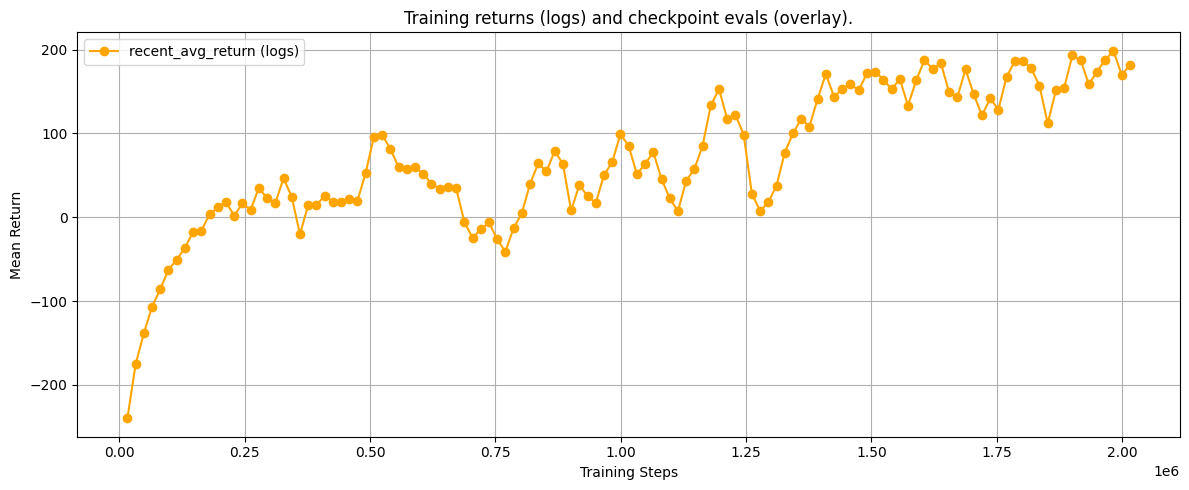

In [18]:
#!/usr/bin/env python3
"""
analyze_and_plot_checkpoints.py

- Inspect checkpoints to find plausible evaluation metrics (return_avg_mean).
- Parse logs for recent_avg_return and learning rate traces.
- Optionally evaluate checkpoints deterministically if metric is missing.
- Plot logs + checkpoint evals + lr overlay.

Usage (terminal):
    python analyze_and_plot_checkpoints.py --logs logs.txt --ckpt-dir checkpoints --out combined.png --eval-if-missing --eval-episodes 50

Notes:
- If you want automatic deterministic checkpoint evaluation, implement build_model() and act_deterministic().
- The script is defensive and will print diagnostics if it can't find metrics.
"""

import argparse
import re
from pathlib import Path
import math
import sys
import csv
import warnings

# plotting and torch imports
import matplotlib.pyplot as plt
import numpy as np

# optional heavy import, import inside functions to avoid memory issues when not needed
try:
    import torch
except Exception:
    torch = None

# ------------------------------
# Config / candidate keys
# ------------------------------
CHECKPOINT_KEY_CANDIDATES = [
    "return_avg_mean",
    "mean_return",
    "metrics.return_avg_mean",
    "metrics.mean_return",
    "eval.return_avg_mean",
    "eval.mean_return",
    "results.return_avg_mean",
    "evaluation.return_avg_mean",
    "eval/return_avg_mean",
]

LR_PATTERNS = [
    re.compile(r"lr[:=]\s*([0-9]*\.?[0-9]+(?:e[+-]?\d+)?)", re.IGNORECASE),
    re.compile(r"learning_rate[:=]\s*([0-9]*\.?[0-9]+(?:e[+-]?\d+)?)", re.IGNORECASE),
    re.compile(r"policy_lr[:=]\s*([0-9]*\.?[0-9]+(?:e[+-]?\d+)?)", re.IGNORECASE),
    re.compile(r"current_lr[:=]\s*([0-9]*\.?[0-9]+(?:e[+-]?\d+)?)", re.IGNORECASE),
]

STEP_RECENT_PATTERN = re.compile(
    r"Steps:\s*([0-9]+)\s*/\s*([0-9]+)[^\n]*recent[_ ]?avg[_ ]?return:\s*([+-]?[0-9]*\.?[0-9]+)",
    re.IGNORECASE,
)
ALTERNATE_STEP_PATTERN = re.compile(
    r"(?:Step|step|steps|update|iter)[:=]?\s*([0-9]+)[^\n]{0,60}recent[_ ]?avg[_ ]?return[:=]?\s*([+-]?[0-9]*\.?[0-9]+)",
    re.IGNORECASE,
)

# ------------------------------
# Utility functions
# ------------------------------
def extract_step_from_name(name: str):
    digits = re.findall(r"\d+", name)
    if not digits:
        return None
    return int("".join(digits))


def try_get_value_from_obj(obj, key_path):
    parts = key_path.split(".")
    cur = obj
    for p in parts:
        if isinstance(cur, dict) and p in cur:
            cur = cur[p]
        else:
            return None
    return cur


def find_metric_in_checkpoint(ckpt):
    """Try candidate keys and heuristics to find plausible 'mean return' metric in checkpoint dict."""
    # candidates first
    for k in CHECKPOINT_KEY_CANDIDATES:
        if "." in k:
            val = try_get_value_from_obj(ckpt, k)
            if val is not None:
                try:
                    return float(val)
                except:
                    pass
        else:
            if isinstance(ckpt, dict) and k in ckpt:
                try:
                    return float(ckpt[k])
                except:
                    pass

    # nested containers heuristics
    for rootk in ["metrics", "eval", "results", "logs", "info", "evaluation"]:
        if isinstance(ckpt, dict) and rootk in ckpt and isinstance(ckpt[rootk], dict):
            for subk in ["return_avg_mean", "mean_return", "avg_return", "eval_return"]:
                if subk in ckpt[rootk]:
                    try:
                        return float(ckpt[rootk][subk])
                    except:
                        pass

    # scan for numeric candidates and pick plausible ones
    candidates = []
    def scan(d, path=""):
        if isinstance(d, dict):
            for kk, vv in d.items():
                scan(vv, f"{path}.{kk}" if path else kk)
        elif isinstance(d, (float, int)):
            candidates.append((path, float(d)))
        elif isinstance(d, (list, tuple)) and len(d)>0 and all(isinstance(x,(int,float)) for x in d[:20]):
            candidates.append((path + " (list_mean)", float(sum(d)/len(d))))
    scan(ckpt)

    # filter plausible ranges for LunarLander-ish returns (heuristic)
    plausible = [(k,v) for (k,v) in candidates if -5000 < v < 5000]
    if not plausible:
        return None

    # choose candidate whose absolute value is large but plausible (often mean returns are > 0 later)
    plausible_sorted = sorted(plausible, key=lambda x: abs(x[1]), reverse=True)
    return float(plausible_sorted[0][1])


# ------------------------------
# Logging / parsing functions
# ------------------------------
def parse_logs(logfile: Path):
    text = logfile.read_text(encoding="utf-8", errors="ignore")
    recent_rows = []
    for m in STEP_RECENT_PATTERN.finditer(text):
        step = int(m.group(1))
        total = int(m.group(2))
        recent = float(m.group(3))
        recent_rows.append((step, recent))
    if not recent_rows:
        for m in ALTERNATE_STEP_PATTERN.finditer(text):
            step = int(m.group(1))
            recent = float(m.group(2))
            recent_rows.append((step, recent))

    # parse lr rows (try to associate with step)
    lr_rows = []
    lines = text.splitlines()
    for idx, line in enumerate(lines):
        # try to find step in the line
        step_search = re.search(r"(?:Steps:|steps:|Step:|step:|update:|iter:)\s*([0-9]+)", line, re.IGNORECASE)
        lr_val = None
        for pat in LR_PATTERNS:
            mm = pat.search(line)
            if mm:
                try:
                    lr_val = float(mm.group(1))
                    break
                except:
                    pass
        if lr_val is not None:
            if step_search:
                step = int(step_search.group(1))
                lr_rows.append((step, lr_val))
            else:
                # search back a few lines for step
                found_step = None
                for back in range(1,4):
                    if idx-back < 0:
                        break
                    sline = lines[idx-back]
                    ssearch = re.search(r"(?:Steps:|steps:|Step:|step:|update:|iter:)\s*([0-9]+)", sline, re.IGNORECASE)
                    if ssearch:
                        found_step = int(ssearch.group(1))
                        break
                if found_step is not None:
                    lr_rows.append((found_step, lr_val))
                else:
                    # append with None step - will be ignored in plotting
                    lr_rows.append((None, lr_val))

    recent_rows = sorted(recent_rows, key=lambda x: x[0]) if recent_rows else []
    lr_rows = [r for r in lr_rows if r[0] is not None]
    lr_rows = sorted(lr_rows, key=lambda x: x[0]) if lr_rows else []
    return recent_rows, lr_rows


# ------------------------------
# Checkpoint reading
# ------------------------------
def read_checkpoints(ckpt_dir: Path):
    if not ckpt_dir.exists():
        return []
    files = sorted([p for p in ckpt_dir.iterdir() if p.suffix in [".pt", ".pth", ".zip"]])
    ckpt_rows = []
    if not files:
        return ckpt_rows

    if torch is None:
        print("Warning: torch not available; can't inspect checkpoint files. Install PyTorch to inspect.")
        return ckpt_rows

    for f in files:
        try:
            data = torch.load(str(f), map_location="cpu")
        except Exception as e:
            print(f"Warning: failed to load {f.name}: {e}")
            continue
        metric = find_metric_in_checkpoint(data)
        if metric is not None:
            step = extract_step_from_name(f.name)
            if step is None:
                # try to read step inside checkpoint
                if isinstance(data, dict):
                    for k in ("step","update","num_updates","training_step","global_step"):
                        if k in data and isinstance(data[k], (int,float)):
                            step = int(data[k]); break
            if step is None:
                print(f"Skipping {f.name} — no step extracted")
                continue
            ckpt_rows.append((step, float(metric), f.name))
            print(f"Found metric in {f.name}: step={step}, metric={metric}")
        else:
            print(f"No metric found in {f.name}; will consider evaluating if requested.")
    ckpt_rows = sorted(ckpt_rows, key=lambda x: x[0])
    return ckpt_rows


# ------------------------------
# Optional deterministic evaluation (user must fill hooks)
# ------------------------------
def build_model():
    """
    USER ACTION REQUIRED if you want automatic deterministic evaluation.
    Replace with your model constructor and weight-loading logic.
    Must return a PyTorch model object (eval mode).
    """
    raise NotImplementedError("Implement build_model() for automatic checkpoint evaluation.")


def load_weights_into_model(model, ckpt_path: Path):
    """Try common load strategies; adapt to your checkpoint structure."""
    data = torch.load(str(ckpt_path), map_location="cpu")
    if isinstance(data, dict):
        if "model_state_dict" in data:
            model.load_state_dict(data["model_state_dict"])
        elif "state_dict" in data:
            model.load_state_dict(data["state_dict"])
        else:
            # try to load data as full state_dict
            try:
                model.load_state_dict(data)
            except Exception as e:
                print("Warning: couldn't load weights automatically:", e)
    else:
        # data is not dict; cannot load
        raise RuntimeError("Checkpoint format not recognized for automatic load.")


def make_eval_env():
    """USER ACTION: return a Gym/Gymnasium env configured for deterministic eval"""
    try:
        import gymnasium as gym
    except Exception:
        import gym
    return gym.make("LunarLander-v3")  # adjust if needed


def act_deterministic(model, obs):
    """
    USER ACTION REQUIRED: implement deterministic action selection for your model.
    Example: if model returns logits, do argmax; if actor returns distribution, pick mode.
    """
    raise NotImplementedError("Implement act_deterministic(model, obs) for auto-eval.")


def evaluate_checkpoints_deterministic(ckpt_dir: Path, out_csv: Path, n_episodes=50):
    """
    Iterate over ckpts, load model, evaluate n_episodes deterministically, save CSV results.
    Requires build_model() and act_deterministic() to be implemented by user.
    """
    if torch is None:
        raise RuntimeError("PyTorch required for deterministic evaluation.")

    results = []
    for f in sorted(ckpt_dir.iterdir()):
        if f.suffix not in [".pt", ".pth", ".zip"]:
            continue
        try:
            model = build_model()
            load_weights_into_model(model, f)
            model.eval()
        except Exception as e:
            print(f"Failed to load {f.name}: {e}")
            continue

        env = make_eval_env()
        returns = []
        for ep in range(n_episodes):
            obs, info = env.reset(seed=ep)
            done = False
            total = 0.0
            while True:
                a = act_deterministic(model, obs)
                obs, reward, terminated, truncated, info = env.step(a)
                total += reward
                if terminated or truncated:
                    break
            returns.append(total)
        env.close()
        mean = float(np.mean(returns))
        std = float(np.std(returns))
        step = extract_step_from_name(f.name) or 0
        print(f"Evaluated {f.name}: step={step}, mean={mean:.2f}, std={std:.2f}")
        results.append((step, mean, std, f.name))

    # save csv
    with open(out_csv, "w", newline="") as fh:
        writer = csv.writer(fh)
        writer.writerow(["step","mean_return","std_return","ckpt_name"])
        for row in sorted(results):
            writer.writerow(row)
    print("Saved deterministic eval results to", out_csv)
    return results


# ------------------------------
# Plotting
# ------------------------------
def plot_combined(recent_rows, ckpt_rows, lr_rows, out_path: Path, show=False):
    plt.figure(figsize=(12,5))
    ax = plt.gca()

    if recent_rows:
        steps_r, vals_r = zip(*recent_rows)
        ax.plot(steps_r, vals_r, marker="o", linestyle="-", color="orange", label="recent_avg_return (logs)")

    if ckpt_rows:
        steps_c = [r[0] for r in ckpt_rows]
        vals_c = [r[1] for r in ckpt_rows]
        ax.plot(steps_c, vals_c, marker="x", linestyle="", color="tab:blue", label="checkpoint return_avg_mean")

    if lr_rows:
        ax2 = ax.twinx()
        steps_lr, vals_lr = zip(*lr_rows)
        ax2.plot(steps_lr, vals_lr, linestyle="--", color="green", label="learning_rate")
        ax2.set_ylabel("Learning rate")
        # log scale often useful
        try:
            ax2.set_yscale("log")
        except Exception:
            pass

    ax.set_xlabel("Training Steps")
    ax.set_ylabel("Mean Return")
    ax.set_title("Training returns (logs) and checkpoint evals (overlay).")
    ax.grid(True)

    lines, labels = ax.get_legend_handles_labels()
    if lr_rows:
        lines2, labels2 = ax2.get_legend_handles_labels()
        lines += lines2; labels += labels2
    ax.legend(lines, labels, loc="upper left")

    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    print("Saved combined plot to", out_path.resolve())
    if show:
        plt.show()


# ------------------------------
# Quick inspector for a single checkpoint (helpful)
# ------------------------------
def inspect_checkpoint_one(ckpt_path: Path, top_n=20):
    if torch is None:
        print("PyTorch not available; cannot inspect checkpoint.")
        return
    if not ckpt_path.exists():
        print("Checkpoint not found:", ckpt_path)
        return
    data = torch.load(str(ckpt_path), map_location="cpu")
    if not isinstance(data, dict):
        print("Checkpoint root is not dict; type:", type(data))
        return
    print("Top-level keys:", list(data.keys())[:80])
    # collect numeric entries
    nums = []
    def collect(d, path=""):
        if isinstance(d, dict):
            for k,v in d.items():
                collect(v, f"{path}.{k}" if path else k)
        elif isinstance(d, (int,float)):
            nums.append((path, float(d)))
        elif isinstance(d, (list,tuple)) and len(d)>0 and all(isinstance(x,(int,float)) for x in d[:20]):
            nums.append((path + " (list_mean)", float(sum(d)/len(d))))
    collect(data)
    nums_sorted = sorted(nums, key=lambda x: abs(x[1]), reverse=True)[:top_n]
    print("Top numeric candidates (path = value):")
    for p,v in nums_sorted:
        print(p, "=", v)


# ------------------------------
# CLI main
# ------------------------------
def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--logs", default="logs.txt", help="Path to training logs")
    parser.add_argument("--ckpt-dir", default="checkpoints_lunarlander", help="Checkpoint folder")
    parser.add_argument("--out", default="combined_training_plot.png", help="Output image")
    parser.add_argument("--show", action="store_true", help="Show plot")
    parser.add_argument("--eval-if-missing", action="store_true", help="If checkpoints lack metrics, run deterministic eval (requires implementing hooks)")
    parser.add_argument("--eval-episodes", type=int, default=50, help="Episodes per checkpoint for deterministic eval")
    parser.add_argument("--inspect-one", default=None, help="Inspect a single checkpoint and print numeric candidates (path to file)")
    args, unknown = parser.parse_known_args()
    if unknown:
        print("Ignoring unknown args:", unknown)

    logf = Path(args.logs)
    ckptdir = Path(args.ckpt_dir)
    outpath = Path(args.out)

    # Step 1: parse logs
    recent_rows, lr_rows = ([], [])
    if logf.exists():
        recent_rows, lr_rows = parse_logs(logf)
        print(f"Parsed {len(recent_rows)} recent_avg_return points and {len(lr_rows)} LR points from logs.")
    else:
        print("Log file not found:", logf)

    # Optional inspect one
    if args.inspect_one:
        inspect_checkpoint_one(Path(args.inspect_one))
        return

    # Step 2: read checkpoints for embedded metrics
    ckpt_rows = read_checkpoints(ckptdir) if ckptdir.exists() else []
    print(f"Found {len(ckpt_rows)} checkpoint metrics embedded.")

    # Step 3: if none found and eval-if-missing enabled, evaluate deterministically
    if not ckpt_rows and args.eval_if_missing and ckptdir.exists():
        print("No embedded checkpoint metrics found. Running deterministic evaluation (you must implement build_model/act_deterministic).")
        try:
            results = evaluate_checkpoints_deterministic(ckptdir, out_csv=Path("ckpt_eval_results.csv"), n_episodes=args.eval_episodes)
            # convert to ckpt_rows format
            ckpt_rows = [(int(r[0]), float(r[1]), r[3]) for r in results]
        except NotImplementedError as nie:
            print("Auto-evaluation not implemented:", nie)
        except Exception as e:
            print("Error during deterministic evaluation:", e)

    # Final: plot combined
    if not recent_rows and not ckpt_rows:
        print("No data to plot. Exiting.")
        return

    plot_combined(recent_rows, ckpt_rows, lr_rows, outpath, show=args.show)

if __name__ == "__main__":
    main()
